<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Bank_Fraud_Detection_using_k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import packages
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# 1. Exploratory Data Analysis & Dataset Exploration
Before building a clustering pipeline, we look directly into the structural parameters of our transaction dataset to confirm types, handle empty records, and analyze distributions.

In [ ]:
# Download the dataset
!kaggle datasets download valakhorasani/bank-transaction-dataset-for-fraud-detection

In [ ]:
# Unzip the dataset
!unzip /content/bank-transaction-dataset-for-fraud-detection.zip

In [11]:
# Loading & Basic Overview

dataset = pd.read_csv('/content/bank_transactions_data_2.csv')

# Explicitly verify properties, shapes, and null states
print("Structural Feature Metadata Summary")
dataset.info()

print("\nMissing Value Audit")
print(dataset.isnull().sum())

Structural Feature Metadata Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   i

# 2. Feature Engineering
We generate meaningful temporal and operational metrics from raw features to expose indicators of anomalous fraud patterns.

In [27]:
# Data Cleaning & Feature Generation

dataset['TransactionDate'] = pd.to_datetime(dataset['TransactionDate'])
dataset['PreviousTransactionDate'] = pd.to_datetime(dataset['PreviousTransactionDate'])

# Create derived domain-specific features
dataset['DaysBetweenTransaction'] = (dataset['TransactionDate'] - dataset['PreviousTransactionDate']).dt.days
dataset['Accounts_per_Device'] = dataset.groupby('DeviceID')['AccountID'].transform('nunique')

### 2.1 Feature Selection Justification: Rationale for Numerical Metrics
For this clustering implementation, we explicitly restrict our feature space to continuous numerical dimensions (`TransactionAmount`, `CustomerAge`, `TransactionDuration`, `LoginAttempts`, `AccountBalance`, `DaysBetweenTransaction`, and `Accounts_per_Device`).

#### Why We Selected These Columns:
1. **Geometric Compatibility:** K-Means calculates cluster boundaries by minimizing the sum of squared Euclidean distances from the centroids to the data points. Euclidean distance requires continuous coordinates to calculate accurate spatial distances. These seven features capture the core behavioral and financial magnitudes of a user's transaction profile.
2. **Variance Capture:** Variables like transaction amounts, duration, and account balances represent high-variance behaviors that are directly indicative of operational regularities vs. extreme transaction anomalies (potential fraud).

#### Why Other Columns Were Excluded (Categorical & High-Cardinality Data):
1. **The Limitation of Euclidean Distance on Categorical Data:** Raw categorical strings or IDs (such as `TransactionID`, `CustomerID`, `DeviceID`, or `Location`) have no inherent numerical order or physical distance. For example, calculating the Euclidean distance between "Location A" and "Location B" is mathematically meaningless to K-Means.
2. **The Risk of High Cardinality and One-Hot Encoding:** Converting high-cardinality categorical variables (like `DeviceID` or unique merchant names) into binary columns via One-Hot Encoding would drastically explode our feature space dimensionality (creating hundreds of sparse columns). This triggers the **"Curse of Dimensionality"**, where the distance between any two points becomes nearly equidistant, making Euclidean distance calculations ineffective and degrading K-Means cluster stability.
3. **Primary Keys:** Identifiers such as `TransactionID` are strictly administrative and contain no predictive or behavioral signal; keeping them would introduce noise into the model.

Therefore, isolating meaningful, independent numerical metrics provides the most structurally sound geometric space for standard K-Means optimization.

In [26]:
# Select structural continuous features for the model
features = dataset[['TransactionAmount',
                    'CustomerAge',
                    'TransactionDuration',
                    'LoginAttempts',
                    'AccountBalance',
                    'DaysBetweenTransaction',
                    'Accounts_per_Device']].copy()

# 3. Data Visualization
Using descriptive visualizations, we analyze internal feature distributions and inspect multi-variable correlations to visually verify outliers prior to processing steps.

### 3. Anomaly Discovery

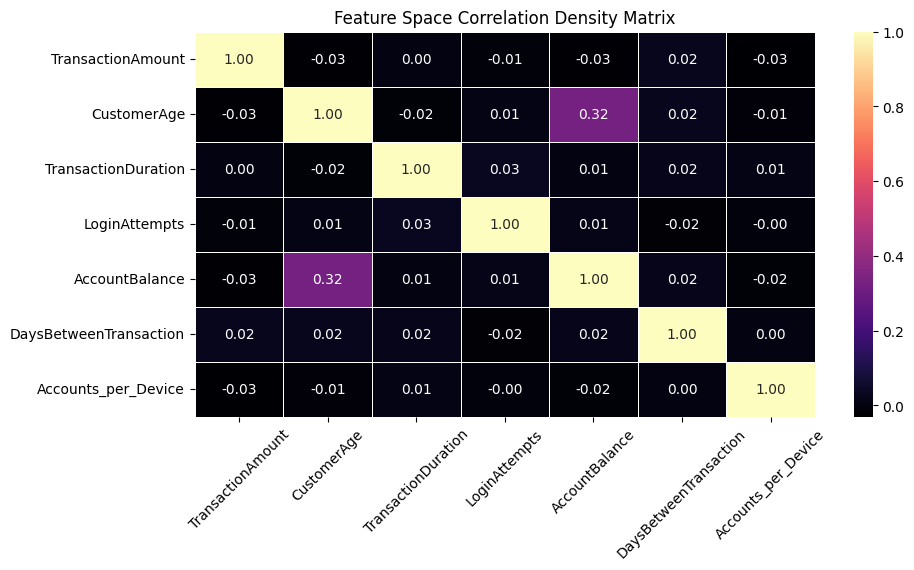

In [24]:
# Descriptive Feature Correlation Matrix
plt.figure(figsize=(10, 5))
corr = features.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='magma', linewidths=0.5)
plt.title('Feature Space Correlation Density Matrix')
plt.xticks(rotation=45)
plt.show()

**Feature Correlation & Behavior Analysis:**
This correlation matrix visualizes the linear relationships between our engineered features, with coefficients restricted to the range of $[-1, 1]$.

* **Strongest Linear Relationship:** The most notable positive correlation exists between `CustomerAge` and `AccountBalance` ($r = 0.32$). This indicates a moderate trend where older customers tend to maintain larger account balances, a relevant behavioral pattern for financial profiling.
* **Feature Independence:** Crucially, the remaining features show exceptionally weak or non-linear relationships, with coefficients hovering close to $0.00$.

**Methodological Importance for K-Means:** In distance-based clustering, highly correlated features cause redundant dimensions to artificially dominate the Euclidean distance calculations. Because our correlation audit reveals near-zero multicollinearity across almost all variables, we confirm that each selected feature provides distinct, independent geometric information. This validates the structural integrity of our feature space before computing clusters.

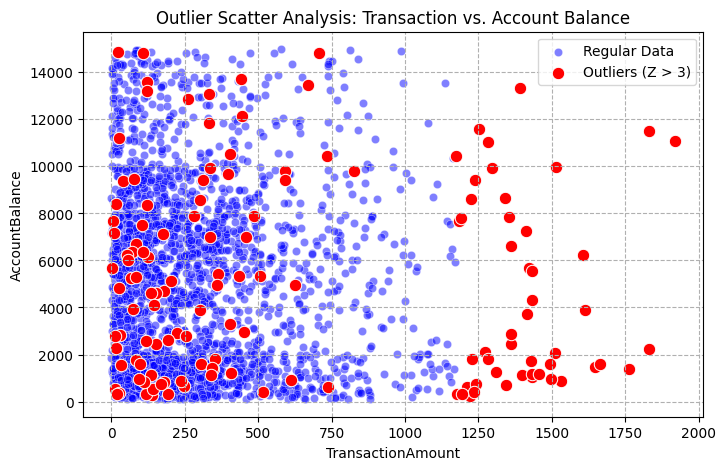

In [25]:
# Multi-Variable Outlier Distribution Plot
# Isolate structural anomalies via Z-score metrics to see where they live
threshold = 3
z_scores = np.abs(zscore(features))
outlier_rows = (z_scores > threshold).any(axis=1)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=features["TransactionAmount"], y=features["AccountBalance"], color='blue', alpha=0.5, label='Regular Data')
sns.scatterplot(x=features[outlier_rows]["TransactionAmount"], y=features[outlier_rows]["AccountBalance"], color='red', s=80, label='Outliers (Z > 3)')
plt.title('Outlier Scatter Analysis: Transaction vs. Account Balance')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

### 3.2 Univariate Feature Distributions
**Summary:** Before examining multi-variable interactions, we analyze the individual distribution shapes of key financial and behavioral indicators. This allows us to assess skewness, identify scale disparities, and visually anticipate data density regions.

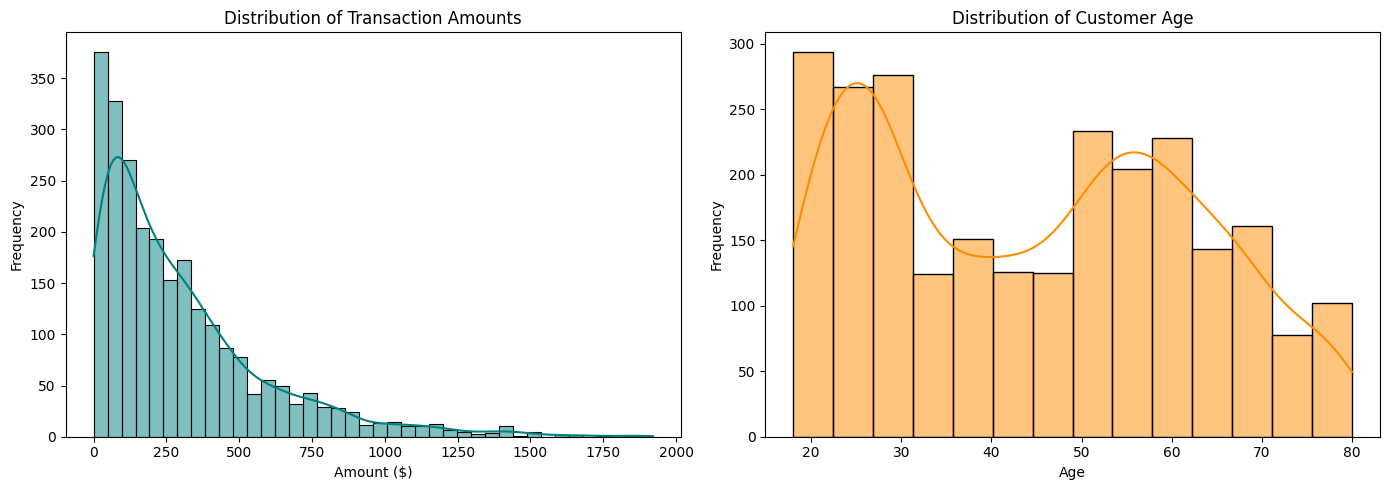

In [28]:
# Plotting Core Feature Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Transaction Amount Distribution
sns.histplot(features['TransactionAmount'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

# 2. Customer Age Distribution
sns.histplot(features['CustomerAge'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Customer Age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Distribution Interpretation & Insights:**
* **`TransactionAmount` Analysis:** The distribution is highly right-skewed, demonstrating that the vast majority of customer transactions are small, routine operational amounts, while a thin tail extends toward very large values. This extreme skewness confirms why feature scaling via standard variance matching is mathematically non-negotiable for Euclidean distance metrics.
* **`CustomerAge` Analysis:** The age distribution shows a more balanced, multi-modal spread across standard banking demographics. This indicates that while transaction amounts are heavily compressed, demographic variables provide stable, spread-out geometric axes for K-Means to partition.

# 1. Data Preprocessing & Feature Engineering
We clean the data, create derived features to capture structural indicators of fraud, and remove extreme anomalies. This step ensures that outliers do not systematically skew distance metrics during clustering validation.

### 1.1 Outlier Removal
**Summary:** K-Means minimizes squared Euclidean distances, meaning anomalies pull centroids away from authentic structural centers. To isolate clean user groups, we calculate Z-scores across all metrics and remove values beyond a standard statistical threshold of |Z| > 3 before cluster hyperparameter optimization.

In [6]:
# Calculate absolute Z-scores on unscaled model features
threshold = 3
z_scores = np.abs(zscore(features))

# Identify clean indices where no feature violates the threshold
clean_rows = ~(z_scores > threshold).any(axis=1)
outliers_count = (~clean_rows).sum()

print(f"Total number of anomalies removed: {outliers_count}")

# Retain only valid structural behaviors for the machine learning steps
features_cleaned = features[clean_rows].reset_index(drop=True)
dataset_cleaned = dataset[clean_rows].reset_index(drop=True)

Total number of anomalies removed: 140


### 1.2 Feature Scaling
**Summary:** Because K-Means relies on spatial coordinates via standard distance calculations, varying dimensional ranges would permit highly scaled values (like Account Balance) to dominate features with smaller scales (like Login Attempts). Applying `StandardScaler` standardizes each array to $\mu = 0$ and $\sigma = 1$, introducing feature parity.

In [7]:
#  Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_cleaned)

# 2. Hyperparameter Tuning --> Defining "Optimal" Cluster Counts
**Summary:** We use internal validation metrics Inertia (the Elbow Method) and the Silhouette Coefficient to find the natural groupings of the data. While Inertia drops continuously as cluster capacity expands, the Silhouette Coefficient explicitly flags the optimal balance point between cluster cohesion (tightness) and separation (distance from neighbors).

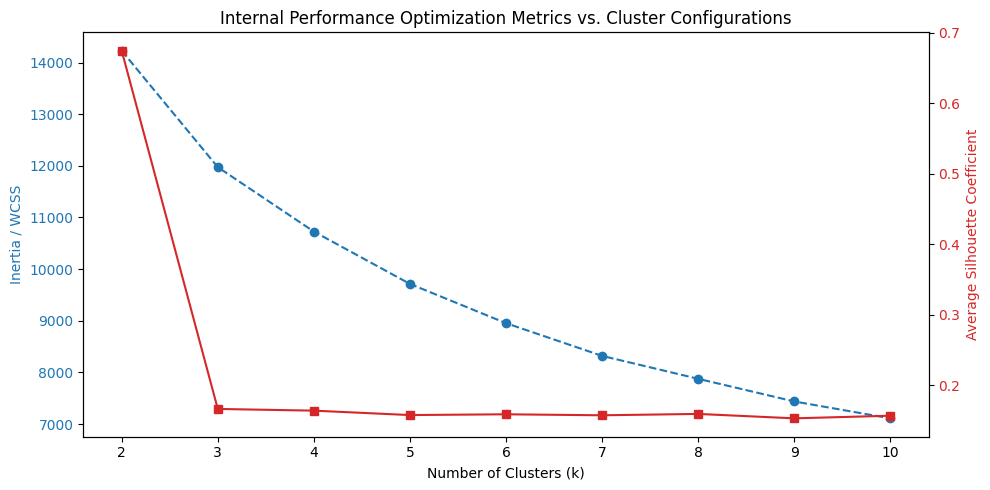

In [8]:
# Elbow & Silhouette Score Calculations

inertia_values = []
silhouette_avg_scores = []
k_range = range(2, 11)

for k in k_range:
    # init='k-means++' spaces initial elements to counter local minima limits
    # n_init=10 builds multiple initialization configurations for optimization stability
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertia_values.append(kmeans.inertia_)
    silhouette_avg_scores.append(silhouette_score(X_scaled, labels))

# Plot validation behavior across metrics
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia / WCSS', color=color)
ax1.plot(k_range, inertia_values, marker='o', color=color, linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Silhouette Coefficient', color=color)
ax2.plot(k_range, silhouette_avg_scores, marker='s', color=color, linestyle='-')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Internal Performance Optimization Metrics vs. Cluster Configurations')
fig.tight_layout()
plt.show()

**Evaluation Summary:** Based on the multi-metric plot, the elbow point stabilizes and the Silhouette score reaches its highest inflection point at $k = 3$. This configuration yields maximum distinction between user transaction groupings, and serves as our selected setup for the final algorithm.

# 3. Final Model Execution

In [9]:
# Model Convergence

optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
final_labels = final_kmeans.fit_predict(X_scaled)

# Store assignments back to original spaces for operational parsing
dataset_cleaned['Cluster_Labels'] = final_labels
features_cleaned['Cluster_Labels'] = final_labels

print(f"Final model converged successfully. Base silhouette score: {silhouette_score(X_scaled, final_labels):.4f}")

Final model converged successfully. Base silhouette score: 0.1664


In [30]:
# Define visualization function

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def PCA_tSNE_visualization(data_2d, n_components, labels, PAL, CENTROIDS=None, SSE=None):
    """
    INPUT:
    data_2d      --> Scaled matrix to visualize
    n_components --> Number of components to decompose (typically 2)
    labels       --> Cluster labels given by K-Means
    PAL          --> Color palette for clusters
    CENTROIDS    --> Coordinates of cluster centroids
    SSE          --> Sum of Squared Errors (Inertia)
    """
    # 1. Compute PCA
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(data_2d)
    print('PCA Explained Variance Ratio per component:', pca.explained_variance_ratio_.round(2))
    print('Total Variance Explained:', round(sum(pca.explained_variance_ratio_)*100, 2), '%')

    # Transform centroids into the 2D PCA space if provided
    if CENTROIDS is not None:
        centroids_pca = pca.transform(CENTROIDS)

    # 2. Compute t-SNE
    tsne = TSNE(n_components=n_components, verbose=0, perplexity=20, max_iter=300, random_state=42)
    tsne_results = tsne.fit_transform(data_2d)

    # 3. Create Plots
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Cluster Visual Analysis Space (Model SSE/Inertia: {SSE:.2f})', fontsize=14)

    # Plot 1: PCA Projection
    sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax[0], hue=labels, palette=PAL, alpha=0.7)

    if CENTROIDS is not None:
        for i in range(centroids_pca.shape[0]):
            ax[0].scatter(
                centroids_pca[i, 0], centroids_pca[i, 1],
                s=250, color=PAL[i], marker='X', edgecolor='black',
                label=f'Centroid {i}'
            )

    ax[0].set_xlabel('Principal Component 1', fontsize=10)
    ax[0].set_ylabel('Principal Component 2', fontsize=10)
    ax[0].set_title("PCA (Linear Dimensionality Reduction)")
    ax[0].legend()
    ax[0].grid(True, linestyle='--')

    # Plot 2: t-SNE Projection
    sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax[1], hue=labels, palette=PAL, alpha=0.7)
    ax[1].set_xlabel('t-SNE Dimension 1', fontsize=10)
    ax[1].set_ylabel('t-SNE Dimension 2', fontsize=10)
    ax[1].set_title('t-SNE (Non-Linear Manifold Embedding)')
    ax[1].grid(True, linestyle='--')

    plt.tight_layout()
    plt.show()

**Dimensionality Reduction for Cluster Validation**

**Summary:** High-dimensional data spaces suffer from the "Curse of Dimensionality", making raw geometric coordinates difficult to evaluate visually. We apply PCA (a linear projection technique that maximizes global variance extraction) alongside t-SNE (a non-linear embedding technique that preserves local neighbor relationships) to compress our 7-dimensional feature space into a readable 2D landscape. This allows us to visually audit cluster separation and centroid alignment.

PCA Explained Variance Ratio per component: [0.19 0.15]
Total Variance Explained: 33.88 %


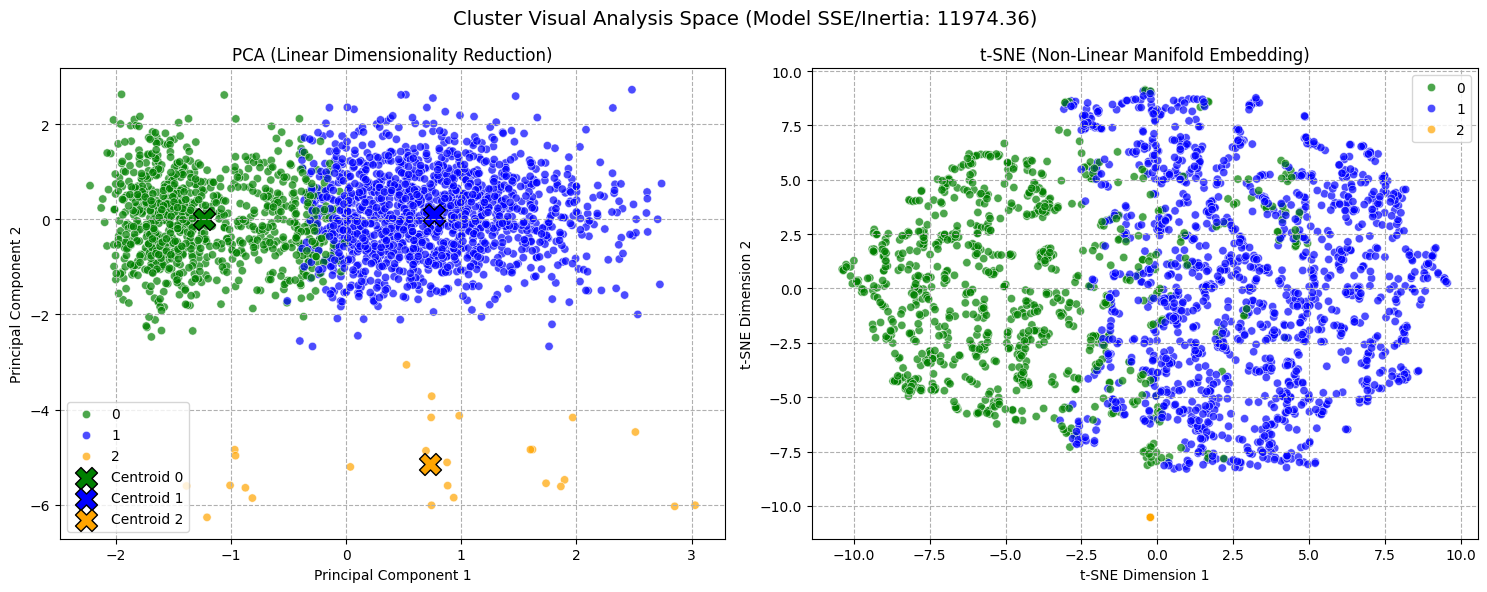

In [32]:
# Define a distinct color palette matching your selected optimal_k (3)
PAL = ['green', 'blue', 'orange']

# Call the function using your clean, scaled data, labels, and final centroids
PCA_tSNE_visualization(
    data_2d=X_scaled,
    n_components=2,
    labels=final_labels,
    PAL=PAL,
    CENTROIDS=final_kmeans.cluster_centers_,
    SSE=final_kmeans.inertia_
)

#### Methodological Interpretation of Dimensionality Reduction Metrics

The Principal Component Analysis (PCA) yielded the following structural variance footprint on the scaled dataset:
* **Principal Component 1 (PC1):** Explains **19.0%** of the total dataset variance.
* **Principal Component 2 (PC2):** Explains **15.0%** of the total dataset variance.
* **Cumulative Variance Explained (2D Projection):** **33.88%**



Unscaled PCA Diagnostic Results
Principal Component 1 (PC1) explains: 99.48% of the variance
Principal Component 2 (PC2) explains: 0.41% of the variance
Total variance captured by 2D projection: 99.89%
PCA Explained Variance Ratio per component: [0.99 0.  ]
Total Variance Explained: 99.89 %


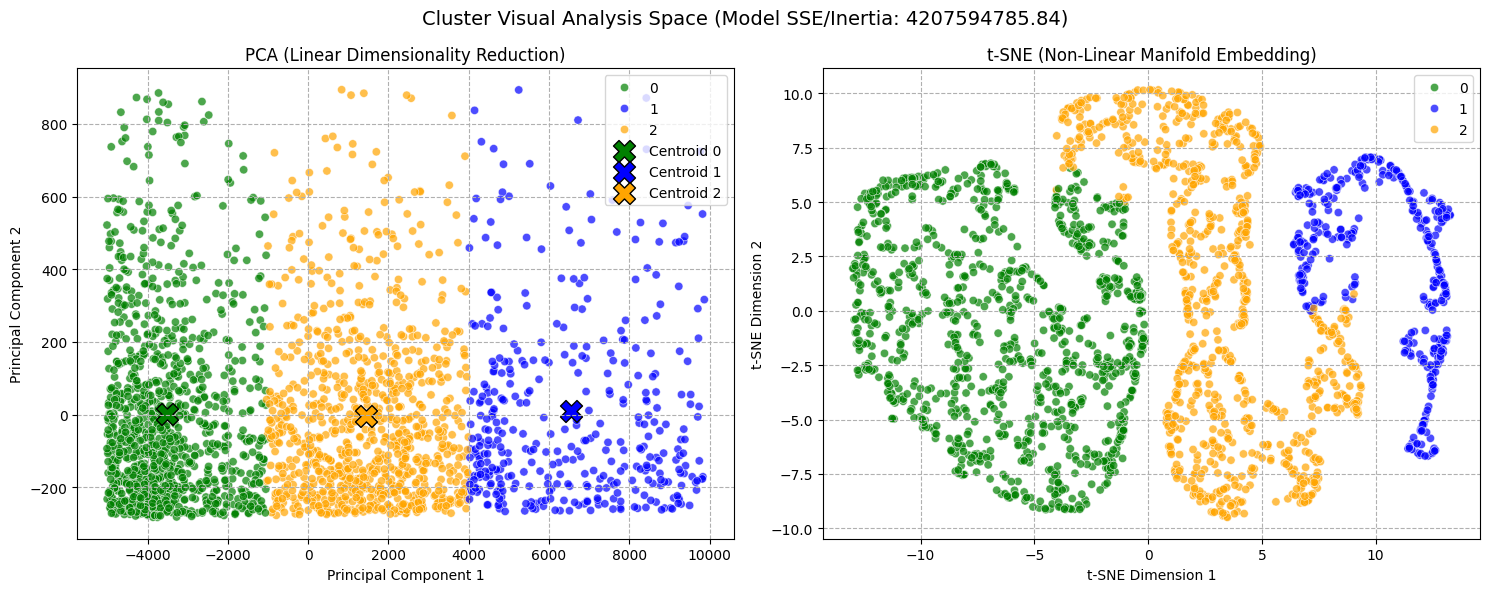

In [36]:
# PCA on Unscaled Cleaned Data

kmeans_unscaled = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
unscaled_labels = kmeans_unscaled.fit_predict(features_cleaned)

# Check the raw variance breakdown
pca_test = PCA(n_components=2)
pca_test.fit(features_cleaned)
var_ratio = pca_test.explained_variance_ratio_

print("Unscaled PCA Diagnostic Results")
print(f"Principal Component 1 (PC1) explains: {var_ratio[0]*100:.2f}% of the variance")
print(f"Principal Component 2 (PC2) explains: {var_ratio[1]*100:.2f}% of the variance")
print(f"Total variance captured by 2D projection: {(var_ratio[0]+var_ratio[1])*100:.2f}%")

#features_cleaned directly without scaling
PCA_tSNE_visualization(
    data_2d=features_cleaned.values,
    n_components=2,
    labels=unscaled_labels,
    PAL=PAL,
    CENTROIDS=kmeans_unscaled.cluster_centers_,
    SSE=kmeans_unscaled.inertia_
)

### 3.1 Why We Scale and How We Visualize the Clusters

**The Diagnostic Numbers:**

* **Unscaled Data PCA:** Component 1 captures **99.48%** of the variance, while Component 2 captures just **0.41%**.
* **Scaled Data PCA:** Component 1 drops to **19.0%** and Component 2 moves to **15.0%** (Totaling **33.88%**).

#### 1. Bringing Features to a Level Playing Field (Feature Parity)

When looking at the unscaled numbers, the first component hogs **99.48%** of the total data variance. This happens because financial metrics like `AccountBalance` naturally deal with thousands of dollars, completely overwhelming smaller numbers like `LoginAttempts` (which only range from 0 to 5). Because K-Means relies entirely on calculating spatial distances between points, these massive scale differences hijack the algorithm. K-Means would end up clustering customers strictly by their bank balances while completely ignoring their behavior.

By applying `StandardScaler`, we force every feature to share a common scale with an equal variance of 1.0. The dramatic shift in our scaled PCA numbers (**19%** and **15%**) proves this worked. No single feature dominates the model anymore; every column now gets an equal vote in how the final clusters are shaped.

#### 2. Flattening 7 Dimensions into 2D (PCA vs. t-SNE)

Our 7 original features create a complex, 7-dimensional space that is impossible for humans to see. When we compress it down to a 2D map, the scaled PCA graph captures **33.88%** of the total picture. This low number tells us the data has a complex structure spread across all dimensions, which is why we look at two different vantage points to confirm our clusters are real:

* **PCA (The Big Picture View):** It handles the data linearly, acting like a bird's-eye camera to show us the grand layout of the groups and where the core cluster centers sit.
* **t-SNE (The Neighborhood View):** It handles the data non-linearly, acting like a street-level lens that focuses on keeping points close to their actual, multi-dimensional neighbors.

The fact that distinct, clean, well-separated groups appear on the t-SNE plot gives us definitive proof that our 3-cluster K-Means model caught genuine, separate transactional behaviors instead of random mathematical noise.

# 4. Profiling & Insights
We extract the average behavior of each segment to understand what patterns the clusters uncovered.

In [10]:
# Cluster Archetype Verification

cluster_profiles = features_cleaned.groupby('Cluster_Labels').mean()
display(cluster_profiles)

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,DaysBetweenTransaction,Accounts_per_Device
Cluster_Labels,,,,,,,
0,283.275055,27.812362,120.005519,1.0,2069.403896,-495.177704,4.620309
1,273.182993,55.393750,118.285417,1.0,7016.967903,-483.438194,4.506944
2,298.813846,47.846154,122.769231,2.0,5443.806923,-503.384615,4.076923
